<a href="https://colab.research.google.com/github/FelipeCostadeSouza/calc_numtrue/blob/main/Atividade_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Atividade 2
Gabriel Moreno Miranda da Silva 187404
Felipe Costa de Souza 187396

Maior float32: 3.4028235e+38
Maior float64: 1.7976931348623157e+308
Valor de r:  0.4
Delta y:  0.0005
dt=0.001, float32: 1000 passos sem overflow.
Valor de r:  0.8
Delta y:  0.0005
dt=0.002, float32: falha no passo 121, t=0.2420 s - overflow encountered in subtract
Valor de r:  0.4000000000000001
Delta y:  0.0005
dt=0.001, float64: 1000 passos sem overflow.
Valor de r:  0.8000000000000002
Delta y:  0.0005
dt=0.002, float64: falha no passo 917, t=1.8340 s - overflow encountered in add


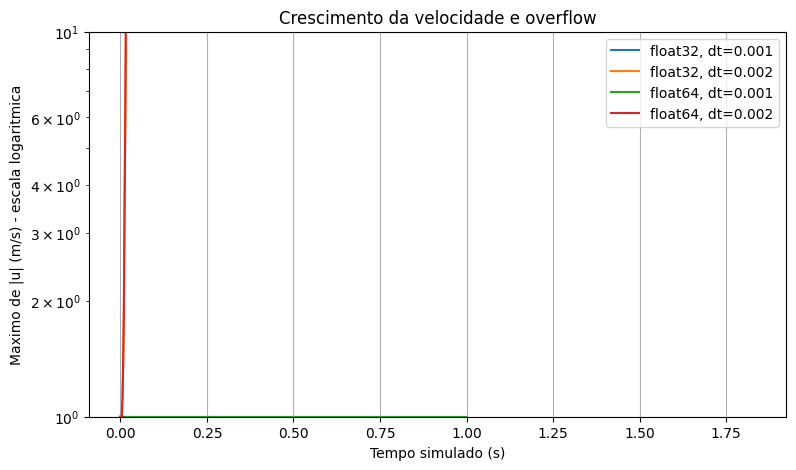

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

def simular(dt, tipo=np.float32, passos=1000, pontos=21):
    """Simula difusao de velocidade e detecta falhas."""
    H = 0.01
    nu = 1e-4
    y = np.linspace(0, H, pontos)
    dy = H / (pontos - 1)
    # Coeficientes no tipo numerico escolhido.
    r = tipo(nu * dt / dy**2)
    print("Valor de r: ", r)
    print("Delta y: ", dy)
    dois = tipo(2)
    # Fluido parado e placa em y=0 em movimento.
    u = np.zeros(pontos, dtype=tipo)
    u[0] = tipo(1)
    tempos = [0.0]
    maximos = [float(np.max(np.abs(u)))]
    falha = None
    # Transforma avisos numericos em excecoes.
    with np.errstate(over="raise", invalid="raise"):
        for passo in range(1, passos + 1):
            try:
                novo = u.copy()
                # Atualiza o interior e preserva as paredes.
                novo[1:-1] = (
                    u[1:-1]
                    + r
                    * (
                        u[2:] - dois * u[1:-1] + u[:-2]
                    )
                )
            except FloatingPointError as erro:
                falha = passo
                print(
                    f"dt={dt}, {tipo.__name__}: "
                    f"falha no passo {passo}, "
                    f"t={passo * dt:.4f} s - {erro}"
                )
                break
            u = novo
            tempos.append(passo * dt)
            maximos.append(float(np.max(np.abs(u))))
    if falha is None:
        print(
            f"dt={dt}, {tipo.__name__}: "
            f"{passos} passos sem overflow."
        )

    return {
        "y": y,
        "u": u,
        "tempos": tempos,
        "maximos": maximos,
        "r": float(r),
        "falha": falha,
        "Delta y": dy,
    }

print("Maior float32:", np.finfo(np.float32).max)
print("Maior float64:", np.finfo(np.float64).max)
resultados = {}
for tipo in (np.float32, np.float64):
    for dt in (0.001, 0.002):
        nome = f"{tipo.__name__}, dt={dt}"
        resultados[nome] = simular(dt, tipo)
plt.figure(figsize=(9, 5))
for nome, resultado in resultados.items():
    plt.semilogy(
        resultado["tempos"],
        resultado["maximos"],
        label=nome
    )
plt.xlabel("Tempo simulado (s)")
plt.ylabel("Maximo de |u| (m/s) - escala logaritmica")
plt.title("Crescimento da velocidade e overflow")
plt.grid(True)
plt.legend()
plt.show()

1 - Verificação da estabilidade:  
Com o Delta y = 0,0005 e delta Tmáx = 0,00125 tanto no caso a quanto para o caso b, quando r = 0,4, haverá estabilidade no programa, pois r está entre 0 e 1/2, quando ele for r=0,8 ele será instavél por ser maior que 1/2, o que permite oscilações.


In [ ]:
# 2- Detecção de overflow.
dados_atividade = {
    "Tipo numérico": ["float32", "float32", "float64", "float64"],
    "Passo de tempo (dt)": [0.001, 0.002, 0.001, 0.002],
    "Valor de r": [
        resultados["float32, dt=0.001"]["r"],
        resultados["float32, dt=0.002"]["r"],
        resultados["float64, dt=0.001"]["r"],
        resultados["float64, dt=0.002"]["r"]
    ],
    "Ocorrência de overflow": [
        "Sim" if resultados["float32, dt=0.001"]["falha"] is not None else "Não",
        "Sim" if resultados["float32, dt=0.002"]["falha"] is not None else "Não",
        "Sim" if resultados["float64, dt=0.001"]["falha"] is not None else "Não",
        "Sim" if resultados["float64, dt=0.002"]["falha"] is not None else "Não"
    ],
    "Iteração da falha": [
        resultados["float32, dt=0.001"]["falha"],
        resultados["float32, dt=0.002"]["falha"],
        resultados["float64, dt=0.001"]["falha"],
        resultados["float64, dt=0.002"]["falha"]
    ]
}

tabela_resultados = pd.DataFrame(dados_atividade)

print(tabela_resultados)

  Tipo numérico  Passo de tempo (dt)  Valor de r Ocorrência de overflow  \
0       float32                0.001         0.4                    Não   
1       float32                0.002         0.8                    Sim   
2       float64                0.001         0.4                    Não   
3       float64                0.002         0.8                    Não   

   Iteração da falha  
0                NaN  
1              121.0  
2                NaN  
3                NaN  


Interpretação física  
O comportamento físico esperado é uma velocidade constante de U, em que U = 1, e como visto pelo gráfico, quando é estável, o U se mantém constante, quando há instabilidade nos dados de entradas, esses erros são propagados ao longo da equação, portanto, o gráfico nos mostra que há aceleração em U, não condizendo com o valor esperado de 1, constante ao longo do tempo

Capacidade de representação  
Alterar a quantidade de bits não remove os erros, se é instável em float32, continua sendo instável em float64. O overflow demora mais para ocorrer em float64 do que em float32, mas isso só acontece por ele possuir uma faixa dinâmica maior.

Refinamento da malha  
O espaçamento deu em torno de 0,00025m e o novo limite de estabilidade é 0,0003125s. O novo r é 1,6, o que é maior que 1/2, portanto, há erros de instabilidade. Testando para DeltaT=0,0002, temos que o r=0,32, e  como 0,32 < 1/2, temos estabilidade, também possivel perceber pelo gráfico.

Valor de r:  0.4000000000000001
Delta y:  0.0005
dt=0.001, float64: 2000 passos sem overflow.
Erro máximo E_infinity: 0.000000 m/s


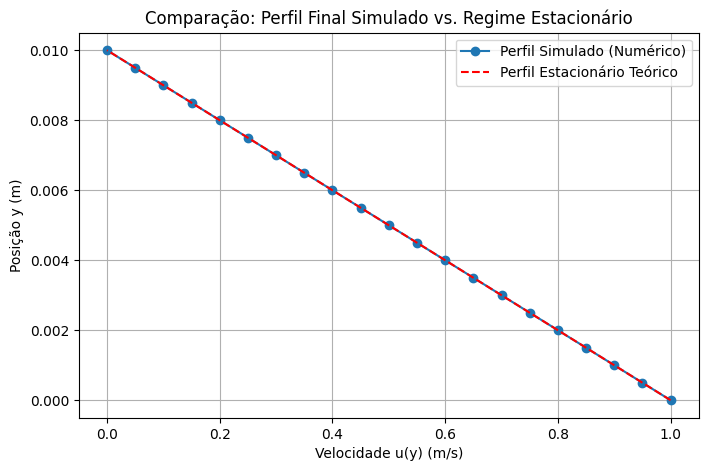

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


res = simular(dt=0.001, tipo=np.float64, passos=2000, pontos=21)

y = res["y"]
u_simulado = res["u"]
H = 0.01
U = 1.0

u_est = U * (1 - y / H)


E_inf = np.max(np.abs(u_simulado - u_est))

print(f"Erro máximo E_infinity: {E_inf:.6f} m/s")


plt.figure(figsize=(8, 5))
plt.plot(u_simulado, y, 'o-', label="Perfil Simulado (Numérico)")
plt.plot(u_est, y, '--r', label="Perfil Estacionário Teórico")
plt.xlabel("Velocidade u(y) (m/s)")
plt.ylabel("Posição y (m)")
plt.title("Comparação: Perfil Final Simulado vs. Regime Estacionário")
plt.grid(True)
plt.legend()
plt.show()

Verificação do perfil de velocidade  
Como E∞ resultou em um valor próximo de 0, significa que o tempo físico foi suficiente para que o fluído chegue ao regime estacionário. Se houver alguma diferença, poderia ser um erro de discretização numérica, ou seja, se o erro que surge eqwuação linear fosse muito diferente da derivada parcial

Conclusão  
Ao refinar a malha, DeltaTmáx diminui drasticamente, o que causará overflow por gerar um número muito grande, assim, reduzir o número de passos é necessário quando refinamos, se quisermos manter a estabilidade da simulação. Quando Deltat é superior há DeltaTmáx, r será maior que 1/2, logo, haverá instabilidade, e como dito anteriormente, se faz necessário aumentar o número de passos.